In [1]:
import sys
sys.path.append('../src')

In [2]:
from gso.manifolds import AlgebraicManifold, plot_manifold
from gso.graph_sampling import GraphSampler
from gso.signal_generation import SignalGenerator
from gso.gso_learning import DiffusionMap, block_descent, laplacian_error_metrics

In [3]:
import time
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.linalg import pinvh

In [4]:
import networkx as nx
from scipy.sparse import csr_matrix

def create_sbm(sizes: list, probs: list, seed=None) -> csr_matrix:
    """
    Generate SBM graph as compressed sparse row matrix.
    
    Parameters:
    sizes : list of ints        # Nodes per community
    probs : 2D list of floats   # Inter/intra-community edge probabilities
    seed  : int (optional)      # Random seed
    
    Returns:
    csr_matrix                  # Sparse adjacency matrix
    """
    g = nx.stochastic_block_model(sizes, probs, seed=seed)
    return nx.adjacency_matrix(g).tocsr()

In [5]:
num_equations = 2
num_variables = 4
max_degree = 4
seed = 22

M = AlgebraicManifold(num_equations, num_variables, max_degree, seed)

sizes = [33, 33, 33]
probs = np.array([[0.3, 0.01, 0.02],
                  [0.01, 0.25, 0.03],
                  [0.02, 0.03, 0.2]])
structure = create_sbm(sizes, probs, seed)

L, W, point_cloud, epsilon = GraphSampler().create_weighted_graph_from_structure(M, structure)
L_dense = L.toarray()
np.fill_diagonal(L_dense, 0)
print(np.shape(L_dense))

(99, 99)


In [6]:
def generate_graph_signals(L, num_signals=1, noise_std=0.0):
    """
    Generate graph signals from a Gaussian distribution with precision matrix L (Laplacian).
    Signals are generated as samples from N(0, L^+), where L^+ is the pseudo-inverse of L,
    aligning with the assumptions of Laplacian learning techniques that model the Laplacian
    as the precision matrix in a Gaussian Markov Random Field.

    Args:
        L (np.ndarray): Laplacian matrix (n x n), assumed to be symmetric and positive semi-definite
        num_signals (int): Number of graph signals to generate (default: 1)
        noise_std (float): Standard deviation of additive Gaussian noise (default: 0.0)

    Returns:
        np.ndarray: Generated graph signals (n x num_signals), where each column is a signal
    """
    n = L.shape[0]
    eigvals, eigvecs = np.linalg.eigh(L)

    tol = 1e-6
    inv_eigvals = np.array([1.0 / ev if ev > tol else 0.0 for ev in eigvals])
    
    sqrt_inv_eigvals = np.sqrt(inv_eigvals)
    L_pinv_sqrt = eigvecs @ np.diag(sqrt_inv_eigvals) @ eigvecs.T
    
    signals = np.zeros((n, num_signals))
    for i in range(num_signals):
        z = np.random.randn(n)
        x = L_pinv_sqrt @ z
        if noise_std > 0:
            x += np.random.randn(n) * noise_std
        signals[:, i] = x

    return signals

In [7]:
# S = SignalGenerator(28).generate_gaussian_signal(L, 500000)
# S2 = SignalGenerator(28).generate_gaussian_signal(L_dense, 500000)

In [8]:
S = generate_graph_signals(L_dense, num_signals=1000)

In [9]:
def plot_trajectories(data, num_trajectories, figsize=(5, 3)):
    selected_points = np.random.choice(S.shape[1], size=num_trajectories, replace=False)

    plt.figure(figsize=figsize)

    colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
    markers = ['o', 's', 'D', '^', 'v', '<', '>']

    for i, col in enumerate(selected_points):
        plt.plot(
            data[:, col],
            color=colors[i % len(colors)],
            marker=markers[i % len(markers)],
            markevery=5,
            linestyle='--',
            linewidth=1,
            label=f'Point {col}'
        )

    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel('Value', fontsize=12)
    plt.title(f'Trajectories of {num_trajectories} Random Point(s) Over {S.shape[0]} Steps', fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

def plot_mean_and_covariance(data, figsize=(6, 3)):
    mean_vector = data.mean(axis=0)
    covariance_matrix = np.cov(data, rowvar=False)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    axes[0].plot(mean_vector, marker='o', linestyle='-')
    axes[0].set_title('Mean Values')
    axes[0].set_xlabel('Node')
    axes[0].grid(True, alpha=0.3)

    cax = axes[1].imshow(pinvh(covariance_matrix), cmap='viridis')
    axes[1].set_title('Inverse Covariance')
    fig.colorbar(cax, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

Signal matrix of shape (99, 1000)
First 10 samples of the first 4 nodes:
[[-1.18567151  1.50947881 -0.29909448 -0.12438653]
 [ 7.26876692  4.06346663 -2.09101406 -2.70910611]
 [-0.35091558 -0.55320801  0.95038357  0.16237511]
 [ 0.13922063  0.73281866  1.80723915  2.07807477]
 [ 0.30408933  0.51731053 -1.00604805  0.30762663]
 [-0.13315581 -0.15907676 -1.69770306 -0.41512783]
 [-0.65659806 -1.16823964  0.83052139  0.8752852 ]
 [-4.5213051  -2.52498758  0.61298654 -0.38383833]
 [ 2.49629276  1.91290136 -2.30240498 -2.13648696]
 [ 3.21466171  1.26772249  0.2251272   0.27976338]]
Std across all nodes for the (99,) samples
Std for the first 10 samples:
[0.67574418 1.96695575 0.72515236 1.37889149 1.00788276 0.84716562
 0.72048089 1.31239398 1.212738   1.09258805]


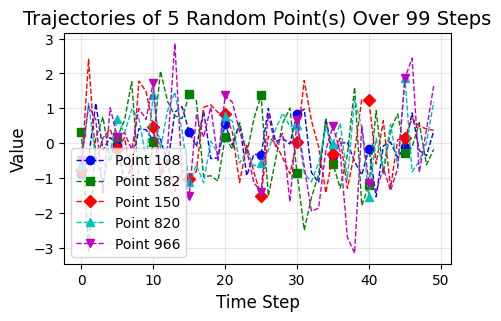

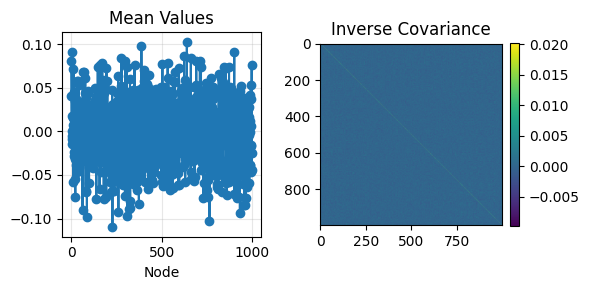

In [10]:
print(f"Signal matrix of shape {np.shape(S)}")
print("First 10 samples of the first 4 nodes:")
print(S[:10,:4])

stddev = np.std(S, axis=1)
print(f"Std across all nodes for the {np.shape(stddev)} samples")
print("Std for the first 10 samples:")
print(stddev[:10])
assert np.all(stddev > 1e-2)

plot_trajectories(S[:50,:], 5)
plot_mean_and_covariance(S)

# MLE without Laplacian constraints

In [11]:
from gso.gso_learning import cgl_fit, glasso_fit

Sigma = np.array(np.cov(S, rowvar=True, bias=False, ddof=1))
print(np.shape(Sigma))
print(f"Running GLASSO")
precision, covariance = glasso_fit(Sigma)
# results_glasso = block_descent(Sigma, 'glasso', A_mask=structure.toarray())
print(f"Running CGL")
precision, covariance = cgl_fit(Sigma, A_mask=structure.toarray())
# results_cgl = block_descent(Sigma, "cgl", A_mask=structure.toarray())

(99, 99)
Running GLASSO
Running CGL


TypingError: Failed in nopython mode pipeline (step: nopython frontend)
Can't unify return type from the following types: Tuple(array(float64, 2d, C), array(float64, 1d, C), array(int64, 1d, C), array(bool, 1d, C), float64, array(float64, 2d, C)), Tuple(array(float64, 2d, C), array(float64, 1d, C), array(int64, 1d, C), array(int64, 1d, C), float64, array(float64, 2d, C))
Return of: IR name '$448return_value.34', type 'Tuple(array(float64, 2d, C), array(float64, 1d, C), array(int64, 1d, C), array(bool, 1d, C), float64, array(float64, 2d, C))', location: 
File "../src/gso/gso_learning/cgl.py", line 26:
def process_node(u, n, A_mask, K, O, C):
    <source elided>
        empty_mask = np.empty(0, dtype=np.bool_)
        return empty_Q, empty_c, not_u, empty_mask, 0.0, np.empty((0,0), dtype=np.float64)
        ^
Return of: IR name '$798return_value.98', type 'Tuple(array(float64, 2d, C), array(float64, 1d, C), array(int64, 1d, C), array(int64, 1d, C), float64, array(float64, 2d, C))', locat

In [13]:
from gso.gso_learning import cgl_fit, glasso_fit

errors_glasso = {
    "frobenius_error": [],
    "spectral_error": [],
    "subspace_error": []
}
errors_pinv = {
    "frobenius_error": [],
    "spectral_error": [],
    "subspace_error": []
}
errors_cgl = {
    "frobenius_error": [],
    "spectral_error": [],
    "subspace_error": []
}
x = []
A = structure.toarray()
L_true = L.toarray()

for i in range(3, 20):
    n_samples = 2**i
    x.append(n_samples)
    print("Generating", n_samples, "samples")
    
    signals = generate_graph_signals(L_true, num_signals=n_samples)
    sample_cov = np.cov(signals, rowvar=True, bias=False, ddof=1)
    assert np.shape(sample_cov) == (99, 99)

    # Inverse Covariance
    error_metrics = laplacian_error_metrics(L_true, np.linalg.pinv(sample_cov))
    errors_pinv["frobenius_error"].append(error_metrics["frobenius_error"])
    errors_pinv["spectral_error"].append(error_metrics["spectral_error"])
    errors_pinv["subspace_error"].append(error_metrics["subspace_error"])

    # GLASSO
    # results_glasso = block_descent(Sigma, 'glasso', A_mask=A)
    precision, covariance = glasso_fit(sample_cov)
    error_metrics = laplacian_error_metrics(L_true, precision)
    
    errors_glasso["frobenius_error"].append(error_metrics["frobenius_error"])
    errors_glasso["spectral_error"].append(error_metrics["spectral_error"])
    errors_glasso["subspace_error"].append(error_metrics["subspace_error"])

    # CGL
    # results_cgl = block_descent(Sigma, 'cgl', A_mask=A)
    precision, covariance = cgl_fit(sample_cov, A_mask=A)
    error_metrics = laplacian_error_metrics(L_true, precision)

    errors_cgl["frobenius_error"].append(error_metrics["frobenius_error"])
    errors_cgl["spectral_error"].append(error_metrics["spectral_error"])
    errors_cgl["subspace_error"].append(error_metrics["subspace_error"])

# Save the data
# data = np.column_stack((x, errors["frobenius_error"], errors["spectral_error"], errors["subspace_error"]))
# np.savetxt('results_invcov.csv', data, delimiter=',', header='n_samples,frobenius_error,spectral_error,subspace_error', comments='')

def plot_errors(errors, title="pinv_cov_error_subplots.png"):
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    
    ax1.plot(x, errors["frobenius_error"], marker='o', linestyle='-', color='b', label='Frobenius Error')
    ax1.set_yscale('log')
    ax1.set_ylabel('Frobenius Error (log scale)')
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax1.legend()
    
    ax2.plot(x, errors["spectral_error"], marker='s', linestyle='--', color='g', label='Spectral Error')
    ax2.set_yscale('log')
    ax2.set_ylabel('Spectral Error (log scale)')
    ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax2.legend()
    
    ax3.plot(x, errors["subspace_error"], marker='^', linestyle='-.', color='r', label='Subspace Error')
    ax3.set_yscale('log')
    ax3.set_xscale('log')
    ax3.set_xlabel('Number of samples (log scale)')
    ax3.set_ylabel('Subspace Error (log scale)')
    ax3.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax3.legend()
    
    plt.tight_layout()
    if title:
        plt.savefig(title, dpi=300, bbox_inches="tight")
    plt.show()

plot_errors(errors_pinv, title=False)
plot_errors(errors_glasso, title=False)
plot_errors(errors_cgl, title=False)

Generating 8 samples


/home/en4624/ghorg/graphdatahub/NetworkInference/src/gso/gso_learning/glasso.py:153: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  W = update_precision_block(W, S, j, lambda_reg)
/home/en4624/ghorg/graphdatahub/NetworkInference/src/gso/gso_learning/glasso.py:153: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 1, 'C', False, aligned=True))
  W = update_precision_block(W, S, j, lambda_reg)
/home/en4624/ghorg/graphdatahub/NetworkInference/.venv/lib/python3.12/site-packages/numba/core/typed_passes.py:336: NumbaPerformanceWarning: 
The keyword argument 'parallel=True' was specified but no transformation for parallel execution was possible.

To find out why, try turning on parallel diagnostics, see https://numba.readthedocs.io/en/stable/user/parallel.html#diagnostics for help.

File

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 97 is different from 98)

In [ ]:
def estimate_covariance(S, A_mask=None, prob_tol=1e-4, inner_tol=1e-6, max_cycle=20):
    """
    Function for estimating a covariance matrix (with symmetry and positive semi-definiteness).
    Uses an iterative block-descent approach.
    
    Inputs:
    - S: sample covariance/input matrix
    - A_mask: optional 0/1 adjacency matrix to mask certain entries (default: None, all entries updated)
    - prob_tol: error tolerance for the optimization problem (default: 1e-4)
    - inner_tol: error tolerance for the QP solver (default: 1e-6)
    - max_cycle: max number of cycles (default: 20)
    
    Outputs:
    - Sigma: estimated covariance matrix
    - Sigma_inv: estimated inverse of Sigma
    - convergence: dictionary with fields 'frobNorm' and 'time'
        'frobNorm': array of normalized differences between estimates between cycles
        'time': runtime of each cycle
    """
    n = S.shape[1]
    
    # If no mask is provided, allow all entries to be updated
    if A_mask is None:
        A_mask = np.ones((n, n))
    
    # Starting value: initialize with diagonal of S to ensure PSD initially
    Sigma_init = np.diag(np.maximum(np.diag(S), 1e-6))
    Sigma_inv = np.diag(1.0 / np.maximum(np.diag(S), 1e-6))
    Sigma = Sigma_init.copy()
    
    # Best output initialization
    Sigma_best = Sigma.copy()
    Sigma_inv_best = Sigma_inv.copy()
    
    # Convergence tracking
    frob_norm = []
    time_counter = []
    converged = False
    cycle = 0
    
    while not converged and cycle < max_cycle:
        Sigma_old = Sigma.copy()
        start_time = time.time()
        
        # Inner loop for block-descent updates
        for u in range(n):
            minus_u = np.setdiff1d(np.arange(n), u)  # Indices excluding u
            
            # Input matrix variables
            s_uu = S[u, u]
            s_u = S[minus_u, u]
            
            # Update inverse block
            c_u = Sigma_inv[minus_u, u]
            c_uu = Sigma_inv[u, u]
            Su_i = Sigma_inv[minus_u[:, None], minus_u] - (c_u[:, None] @ c_u[None, :] / c_uu)
            
            # Block-descent variables
            beta = np.zeros(n-1)
            ind_nz = A_mask[minus_u, u] == 1  # Non-zero indices based on mask
            A_qp = Su_i[ind_nz[:, None], ind_nz]
            b_qp = s_u[ind_nz] / s_uu if s_uu > 1e-6 else 0
            
            # Solve quadratic program without nonnegativity constraint
            beta_qp = qp_solver(A_qp, b_qp, inner_tol)
            beta[ind_nz] = beta_qp  # No sign flip, allow positive/negative values
            sigma_u = beta
            sigma_uu = (1 / s_uu if s_uu > 1e-6 else 1e6) + sigma_u.T @ Su_i @ sigma_u
            
            # Ensure positive diagonal for PSD
            sigma_uu = max(sigma_uu, 1e-6)
            
            # Update the current Sigma
            Sigma[u, u] = sigma_uu
            Sigma[minus_u, u] = sigma_u
            Sigma[u, minus_u] = sigma_u  # Enforce symmetry
            
            # Update the current inverse using Sherman-Woodbury
            cu = Su_i @ sigma_u * s_uu
            cuu = 1 / (sigma_uu - sigma_u.T @ Su_i @ sigma_u) if (sigma_uu - sigma_u.T @ Su_i @ sigma_u) > 1e-6 else 1e6
            Sigma_inv[u, u] = cuu
            Sigma_inv[u, minus_u] = -cu
            Sigma_inv[minus_u, u] = -cu
            Sigma_inv[minus_u[:, None], minus_u] = Su_i + (cu[:, None] @ cu[None, :] / s_uu if s_uu > 1e-6 else 0)
        
        time_interval = time.time() - start_time
        Sigma_best = Sigma.copy()
        Sigma_inv_best = Sigma_inv.copy()
        cycle += 1
        
        # Track time and Frobenius norm
        time_counter.append(time_interval)
        diff_norm = np.linalg.norm(Sigma_old - Sigma, 'fro') / np.linalg.norm(Sigma_old, 'fro')
        frob_norm.append(diff_norm)
        
        print(f"Cycle: {cycle:2d}      |Sigma(t-1)-Sigma(t)|_F/|Sigma(t-1)|_F = {diff_norm:5.8f}")
        
        if cycle > 5:
            if frob_norm[-1] < prob_tol:
                converged = True
                Sigma_best = Sigma.copy()
                Sigma_inv_best = Sigma_inv.copy()
    
    Sigma = Sigma_best
    Sigma_inv = Sigma_inv_best
    
    convergence = {
        'frobNorm': np.array(frob_norm),
        'time': np.array(time_counter)
    }
    
    return Sigma, Sigma_inv, convergence

def qp_solver(A, b, tol=1e-6, max_iter=1000):
    """
    A simple iterative quadratic programming solver for min 0.5 * x^T * A * x - b^T * x.
    No nonnegativity constraints, just solves for unconstrained minimum.
    Returns the optimal solution x.
    """
    n = len(b)
    x = np.zeros(n)
    for _ in range(max_iter):
        x_old = x.copy()
        grad = A @ x - b
        for i in range(n):
            if A[i, i] > 1e-10:  # Avoid division by zero
                x[i] = x[i] - grad[i] / A[i, i]
        if np.linalg.norm(x - x_old) < tol:
            break
    return x

# MLE under Laplacian constraints

* Connectivity (`A_mask`) and symmetry
* Non-positive off-diagonal elements
* Zero sum property
* Regularization for sparsity and structure

In [ ]:
def estimate_ggl(S, A_mask, alpha=0, prob_tol=1e-4, inner_tol=1e-6, max_cycle=20, regularization_type=1):
    """
    Function for finding the best generalized Laplacian estimate under connectivity constraints.
    Returns the optimal solution of the GGL problem.
    
    Inputs:
    - S: sample covariance/input matrix
    - A_mask: 0/1 adjacency matrix where 1s represent connectivity
    - alpha: regularization parameter (default: 0)
    - prob_tol: error tolerance for the optimization problem (default: 1e-4)
    - inner_tol: error tolerance for the nonnegative QP solver (default: 1e-6)
    - max_cycle: max number of cycles (default: 20)
    - regularization_type: two options (default: 1)
        1: |O|_1 (l_1 regularization)
        2: |O|_1,off (l_1 regularization on off-diagonal entries)
    
    Outputs:
    - O: estimated generalized graph Laplacian (Theta)
    - C: estimated inverse of O
    - convergence: dictionary with fields 'frobNorm' and 'time'
        'frobNorm': array of normalized differences between estimates of O between cycles
        'time': runtime of each cycle
    """
    # Variables
    n = S.shape[1]
    
    # Set regularization matrix H_alpha
    if regularization_type == 1:
        H_alpha = alpha * (2 * np.eye(n) - np.ones((n, n)))
    elif regularization_type == 2:
        H_alpha = alpha * (np.eye(n) - np.ones((n, n)))
    else:
        raise ValueError("'regularization_type' must be either 1 or 2.")
    
    K = S + H_alpha
    
    # Starting value
    O_init = np.diag(1.0 / np.diag(K))
    C = np.diag(np.diag(K))
    O = O_init.copy()
    
    # Best output initialization
    O_best = O.copy()
    C_best = C.copy()
    
    # Convergence tracking
    frob_norm = []
    time_counter = []
    converged = False
    cycle = 0
    
    while not converged and cycle < max_cycle:
        O_old = O.copy()
        start_time = time.time()
        
        # Inner loop
        for u in range(n):
            minus_u = np.setdiff1d(np.arange(n), u)  # Indices excluding u
            
            # Input matrix variables
            k_uu = K[u, u]
            k_u = K[minus_u, u]
            
            # Update Ou_inv
            c_u = C[minus_u, u]
            c_uu = C[u, u]
            Ou_i = C[minus_u[:, None], minus_u] - (c_u[:, None] @ c_u[None, :] / c_uu)
            
            # Block-descent variables
            beta = np.zeros(n-1)
            ind_nz = A_mask[minus_u, u] == 1  # Non-zero indices
            A_nnls = Ou_i[ind_nz[:, None], ind_nz]
            b_nnls = k_u[ind_nz] / k_uu
            
            # Block-descent step using a simple nonnegative QP solver
            beta_nnls = nonnegative_qp_solver(A_nnls, b_nnls, inner_tol)
            beta[ind_nz] = -beta_nnls  # Sign flip
            o_u = beta
            o_uu = (1 / k_uu) + o_u.T @ Ou_i @ o_u
            
            # Update the current Theta
            O[u, u] = o_uu
            O[minus_u, u] = o_u
            O[u, minus_u] = o_u
            
            # Update the current Theta inverse
            cu = Ou_i @ o_u * k_uu
            cuu = 1 / (o_uu - o_u.T @ Ou_i @ o_u)
            C[u, u] = cuu
            C[u, minus_u] = -cu
            C[minus_u, u] = -cu
            C[minus_u[:, None], minus_u] = Ou_i + (cu[:, None] @ cu[None, :] / k_uu)
        
        time_interval = time.time() - start_time
        O_best = O.copy()
        C_best = C.copy()
        cycle += 1
        
        # Track time and Frobenius norm
        time_counter.append(time_interval)
        diff_norm = np.linalg.norm(O_old - O, 'fro') / np.linalg.norm(O_old, 'fro')
        frob_norm.append(diff_norm)
        
        print(f"Cycle: {cycle:2d}      |Theta(t-1)-Theta(t)|_F/|Theta(t-1)|_F = {diff_norm:5.8f}")
        
        if cycle > 5:
            if frob_norm[-1] < prob_tol:
                converged = True
                O_best = O.copy()
                C_best = C.copy()
    
    O = O_best
    C = C_best
    
    convergence = {
        'frobNorm': np.array(frob_norm),
        'time': np.array(time_counter)
    }
    
    return O, C, convergence

def nonnegative_qp_solver(A, b, tol=1e-6, max_iter=1000):
    """
    A simple iterative nonnegative quadratic programming solver for the problem:
    min 0.5 * x^T * A * x - b^T * x subject to x >= 0
    Returns the optimal solution x.
    """
    n = len(b)
    x = np.zeros(n)
    for _ in range(max_iter):
        x_old = x.copy()
        for i in range(n):
            grad = A[i, :] @ x - b[i]
            x[i] = max(0, x[i] - grad / (A[i, i] + 1e-10))  # Avoid division by zero
        if np.linalg.norm(x - x_old) < tol:
            break
    return x
